## 제품 유형 2 - 통계 => 이상치 제거하지 않았던 ML용 데이터로 실행해봄
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- 스피어만 상관계수 히트맵

In [55]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [56]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_2 = pd.read_csv('../data/for_ML_process_data_product-2.csv')
df_sensor_2 = pd.read_csv('../data/for_ML_sensor_data_product-2.csv')
df_defects_2 = pd.read_csv('../data/for_ML_defects_data_product-2.csv')
df_original_2 = pd.read_csv('../data/for_ML_overall_product-2.csv')

In [57]:
# 2. 데이터 크기 확인
print(f"제품 1의 process 관련 데이터 크기: {df_process_2.columns}")
print(f"제품 1의 sensor 관련 데이터 크기: {df_sensor_2.columns}")
print(f"제품 1의 defects 관련 데이터 크기: {df_defects_2.columns}")

제품 1의 process 관련 데이터 크기: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time'],
      dtype='object')
제품 1의 sensor 관련 데이터 크기: Index(['melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity'],
      dtype='object')
제품 1의 defects 관련 데이터 크기: Index(['surface_defect', 'structural_defect', 'contamination_defect'], dtype='object')


In [58]:
# 3. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 행을 기준으로 1이 존재하면 불량으로 표현

defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 불량 데이터프레임
df_defects_2['is_defect'] = df_defects_2[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_defects_2_1 = df_defects_2.drop(columns=defect_cols)

# 전체 데이터프레임
df_original_2['is_defect'] = df_original_2[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_original_2_1 = df_original_2.drop(columns=defect_cols)


display(df_defects_2_1.head(5))
df_original_2_1.head(5)

,is_defect
0,0
1,0
2,0
3,0
4,0


,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0
1,4208012_12,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
3,4210014_14,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
4,4211015_15,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0


In [59]:
# 4. 결측치 대체 - 중앙값으로 처리
fill_cols = ["factory_temp", "factory_humidity"]
df_original_2_1[fill_cols] = df_original_2_1[fill_cols].fillna(df_original_2_1[fill_cols].median())

print(df_original_2_1[fill_cols].isna().sum())
print("남아있는 결측치의 개수:", df_original_2_1[fill_cols].isna().sum().sum())

factory_temp        0
factory_humidity    0
dtype: int64
남아있는 결측치의 개수: 0


---
### 2. 정규성 검정

#### 2.1 Shapiro-Wilk 검정

In [60]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):

    print(f"\n{'='*80}")
    print(f"제품 2의 {df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    result_list = []

    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()

        # 값이 1개뿐인 상수형 변수는 검정 불가
        if series.nunique() <= 1:
            result_list.append([col, np.nan, np.nan, "검정불가(상수형)"])
            continue

        stat, p_value = stats.shapiro(series)

        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        result_list.append([col, stat, p_value, result])

    # 결과표 생성
    shapiro_df = pd.DataFrame(result_list, columns=["변수명", "Shapiro 통계량", "p-value", "판정"])
    shapiro_df = shapiro_df.set_index("변수명")

    display(shapiro_df)

    return shapiro_df

In [61]:
shapiro_df_origina2_1 = create_shapiro_summary(df_original_2_1, "공정/센서", exclude_cols=['shot_key', 'is_defect',])


제품 2의 공정/센서 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
velocity_1,0.926543,1.316477e-37,정규성 불만족
velocity_2,0.969190,3.757826e-26,정규성 불만족
velocity_3,0.984859,2.096279e-18,정규성 불만족
high_velocity,0.648671,9.326014e-64,정규성 불만족
cylinder_pressure,0.253951,7.152509e-79,정규성 불만족
rapid_rise_time,0.760192,1.013079e-56,정규성 불만족
biscuit_thickness,0.889750,1.039510e-43,정규성 불만족
clamping_force,0.891286,1.720679e-43,정규성 불만족
cycle_time,0.153969,1.478039e-81,정규성 불만족


#### 2.2 Q-Q Plot

In [62]:
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

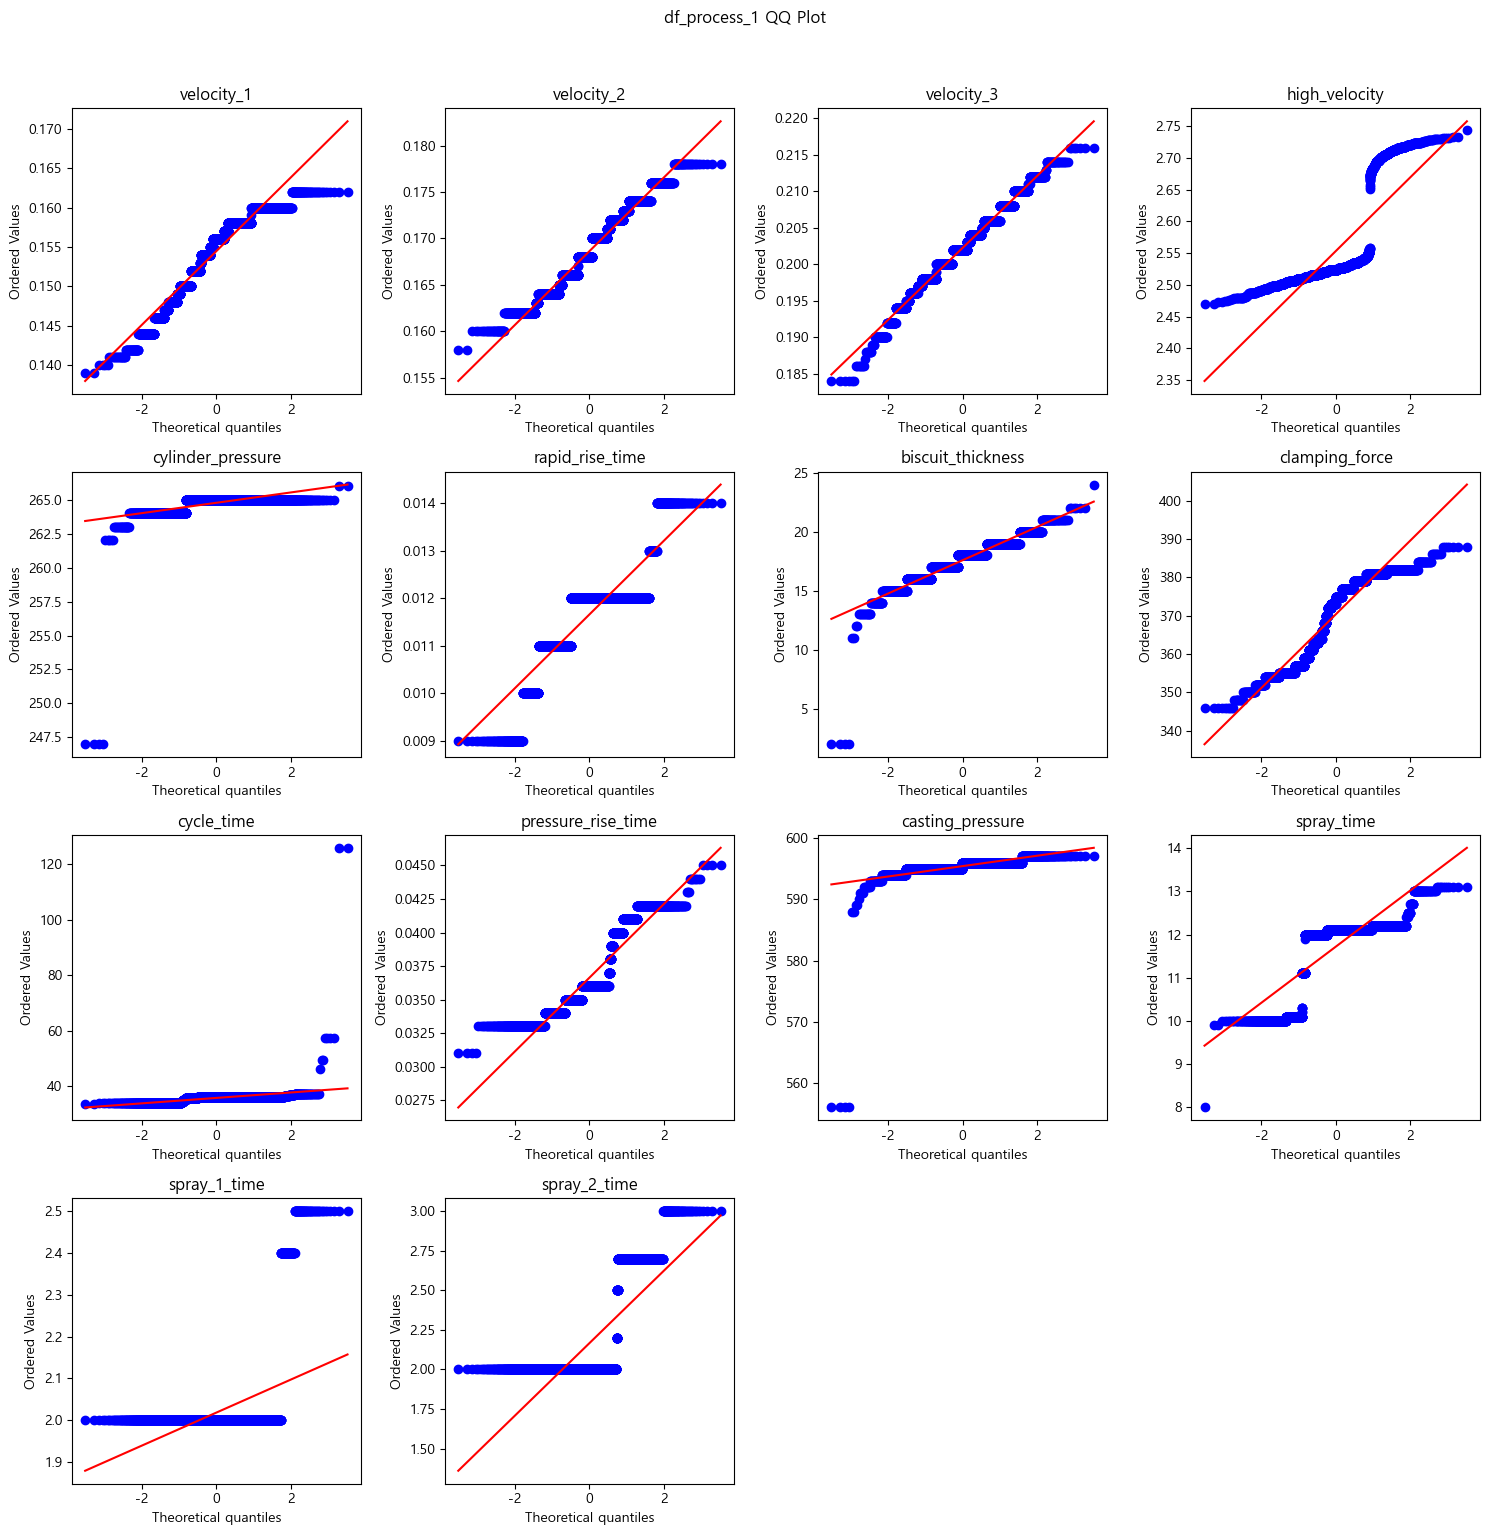

In [63]:
plot_qq_table(df_process_2, 
                title="df_process_1 QQ Plot",
                exclude_cols=[
                    "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 'clamping_force_outlier_flag', 'pressure_rise_time_outlier_flag',
                    'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'spray_2_time_outlier_flag',
                    'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag',  'velocity_2_outlier_flag',  'high_velocity_outlier_flag'], 
    )

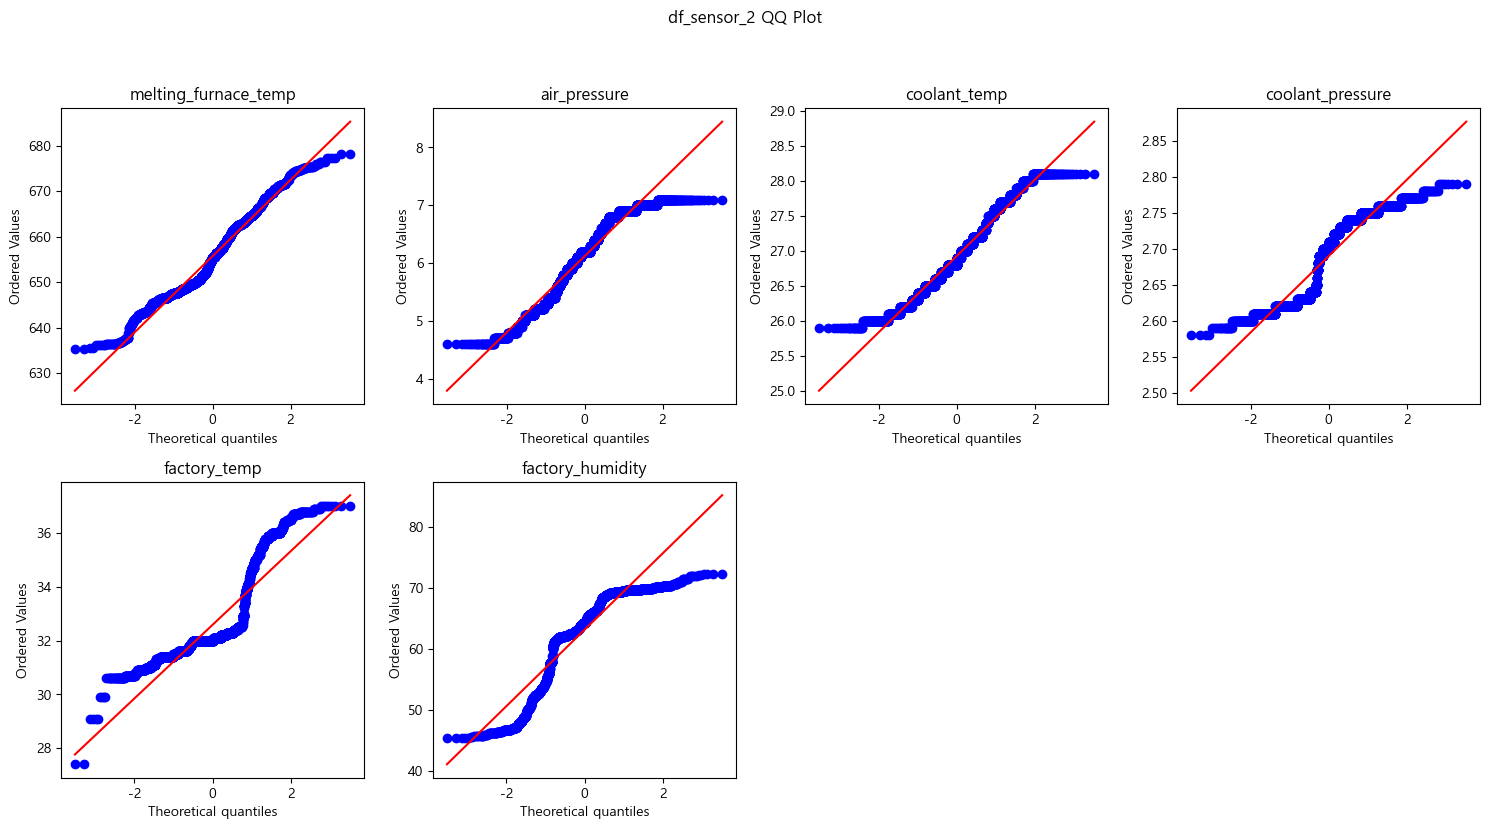

In [64]:
plot_qq_table(df_sensor_2, title="df_sensor_2 QQ Plot")

#### 2.3 Levene 검증

In [65]:
# 연속형 변수 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 연속형 변수 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기준 타깃 시리즈 가져오기
    target_series = defects_df[target_col]
    
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
        
        stat, p_value = stats.levene(group_0, group_1)
        
        if p_value >= alpha:
            result = "등분산 만족"
        else:
            result = "등분산 불만족"
        
        result_list.append([col, stat, p_value, result])
    
    # 결과표 생성
    levene_df = pd.DataFrame(
        result_list,
        columns=["변수명", "Levene 통계량", "p-value", "판정"]
    )
    levene_df = levene_df.set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [66]:
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2_1,
    "is_defect",
    "df_process_2",
    exclude_cols=['shot_key',
        "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 'clamping_force_outlier_flag', 'pressure_rise_time_outlier_flag',
                    'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'spray_2_time_outlier_flag',
                    'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag',  'velocity_2_outlier_flag',  'high_velocity_outlier_flag', 
    ]
)


df_process_2 연속형 변수 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,4.480292,3.436193e-02,등분산 불만족
velocity_2,0.730217,3.928743e-01,등분산 만족
velocity_3,1.830792,1.761259e-01,등분산 만족
high_velocity,188.751329,8.084364e-42,등분산 불만족
cylinder_pressure,5.546086,1.857985e-02,등분산 불만족
rapid_rise_time,0.714535,3.980031e-01,등분산 만족
biscuit_thickness,0.580366,4.462228e-01,등분산 만족
clamping_force,163.045258,1.734345e-36,등분산 불만족
cycle_time,15.444339,8.669984e-05,등분산 불만족


In [67]:
process_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2_1,
    "is_defect",
    "df_sensor_2",
    exclude_cols=['shot_key',
        "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 'clamping_force_outlier_flag', 'pressure_rise_time_outlier_flag',
                    'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'spray_2_time_outlier_flag',
                    'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag',  'velocity_2_outlier_flag',  'high_velocity_outlier_flag', 
    ]
)


df_sensor_2 연속형 변수 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,19.173745,1.230211e-05,등분산 불만족
air_pressure,24.267707,8.792250e-07,등분산 불만족
coolant_temp,3.906079,4.819422e-02,등분산 불만족
coolant_pressure,7.258745,7.091103e-03,등분산 불만족
factory_temp,118.987545,3.121050e-27,등분산 불만족
factory_humidity,183.182801,1.223328e-40,등분산 불만족


#### 2.4 상관계수 히트맵

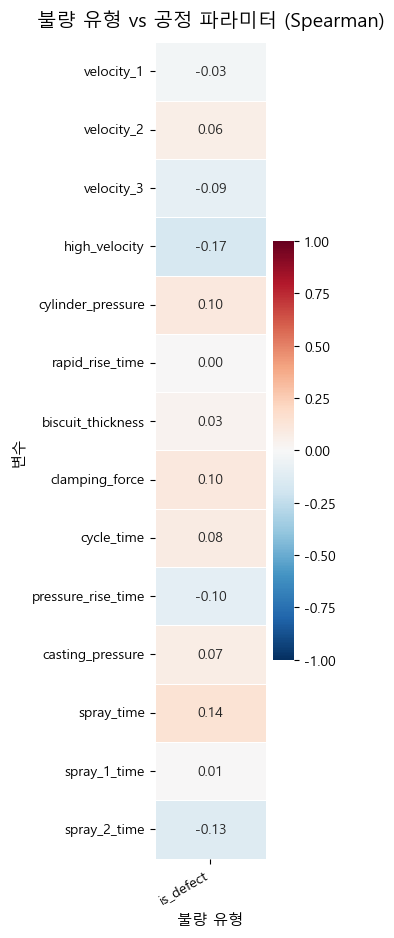

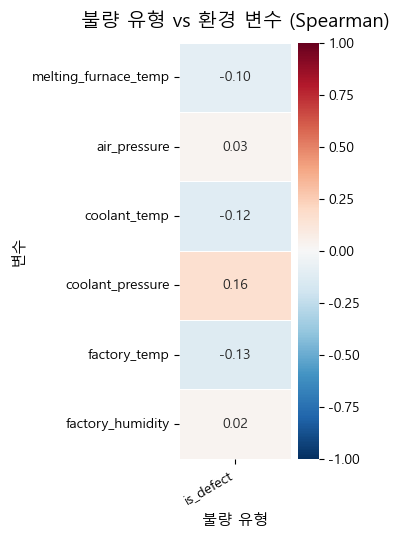

In [68]:
#DEFECT_COLS = [
#    'surface_defect',
#    'structural_defect',
#    'contamination_defect'
#]

DE = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 출력
plot_corr_heatmap(df_original_2_1, DE, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2_1, DE, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

---
---
#### 2.5 개인적으로 확인해보는 중

In [69]:
# 1. 샘플 수 & 불량률
total    = len(df_original_2_1)
n_defect = df_original_2_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"\n=== 기초 현황 ===")
print(f"전체 샘플 : {total:,}개")
print(f"불량      : {int(n_defect):,}개")
print(f"정상      : {int(n_normal):,}개")
print(f"불량률    : {rate:.2f}%")

# 2. 결측치 확인
print("\n=== 결측치 ===")
print(df_original_2_1.isnull().sum())


=== 기초 현황 ===
전체 샘플 : 3,328개
불량      : 946개
정상      : 2,382개
불량률    : 28.43%

=== 결측치 ===
shot_key                0
velocity_1              0
velocity_2              0
velocity_3              0
high_velocity           0
cylinder_pressure       0
rapid_rise_time         0
biscuit_thickness       0
clamping_force          0
cycle_time              0
pressure_rise_time      0
casting_pressure        0
spray_time              0
spray_1_time            0
spray_2_time            0
melting_furnace_temp    0
air_pressure            0
coolant_temp            0
coolant_pressure        0
factory_temp            0
factory_humidity        0
is_defect               0
dtype: int64


In [70]:
# 박스플롯 함수
import math

def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)  # 올림 나눗셈

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#4C72B0", "불량": "#DD8452"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 빈 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

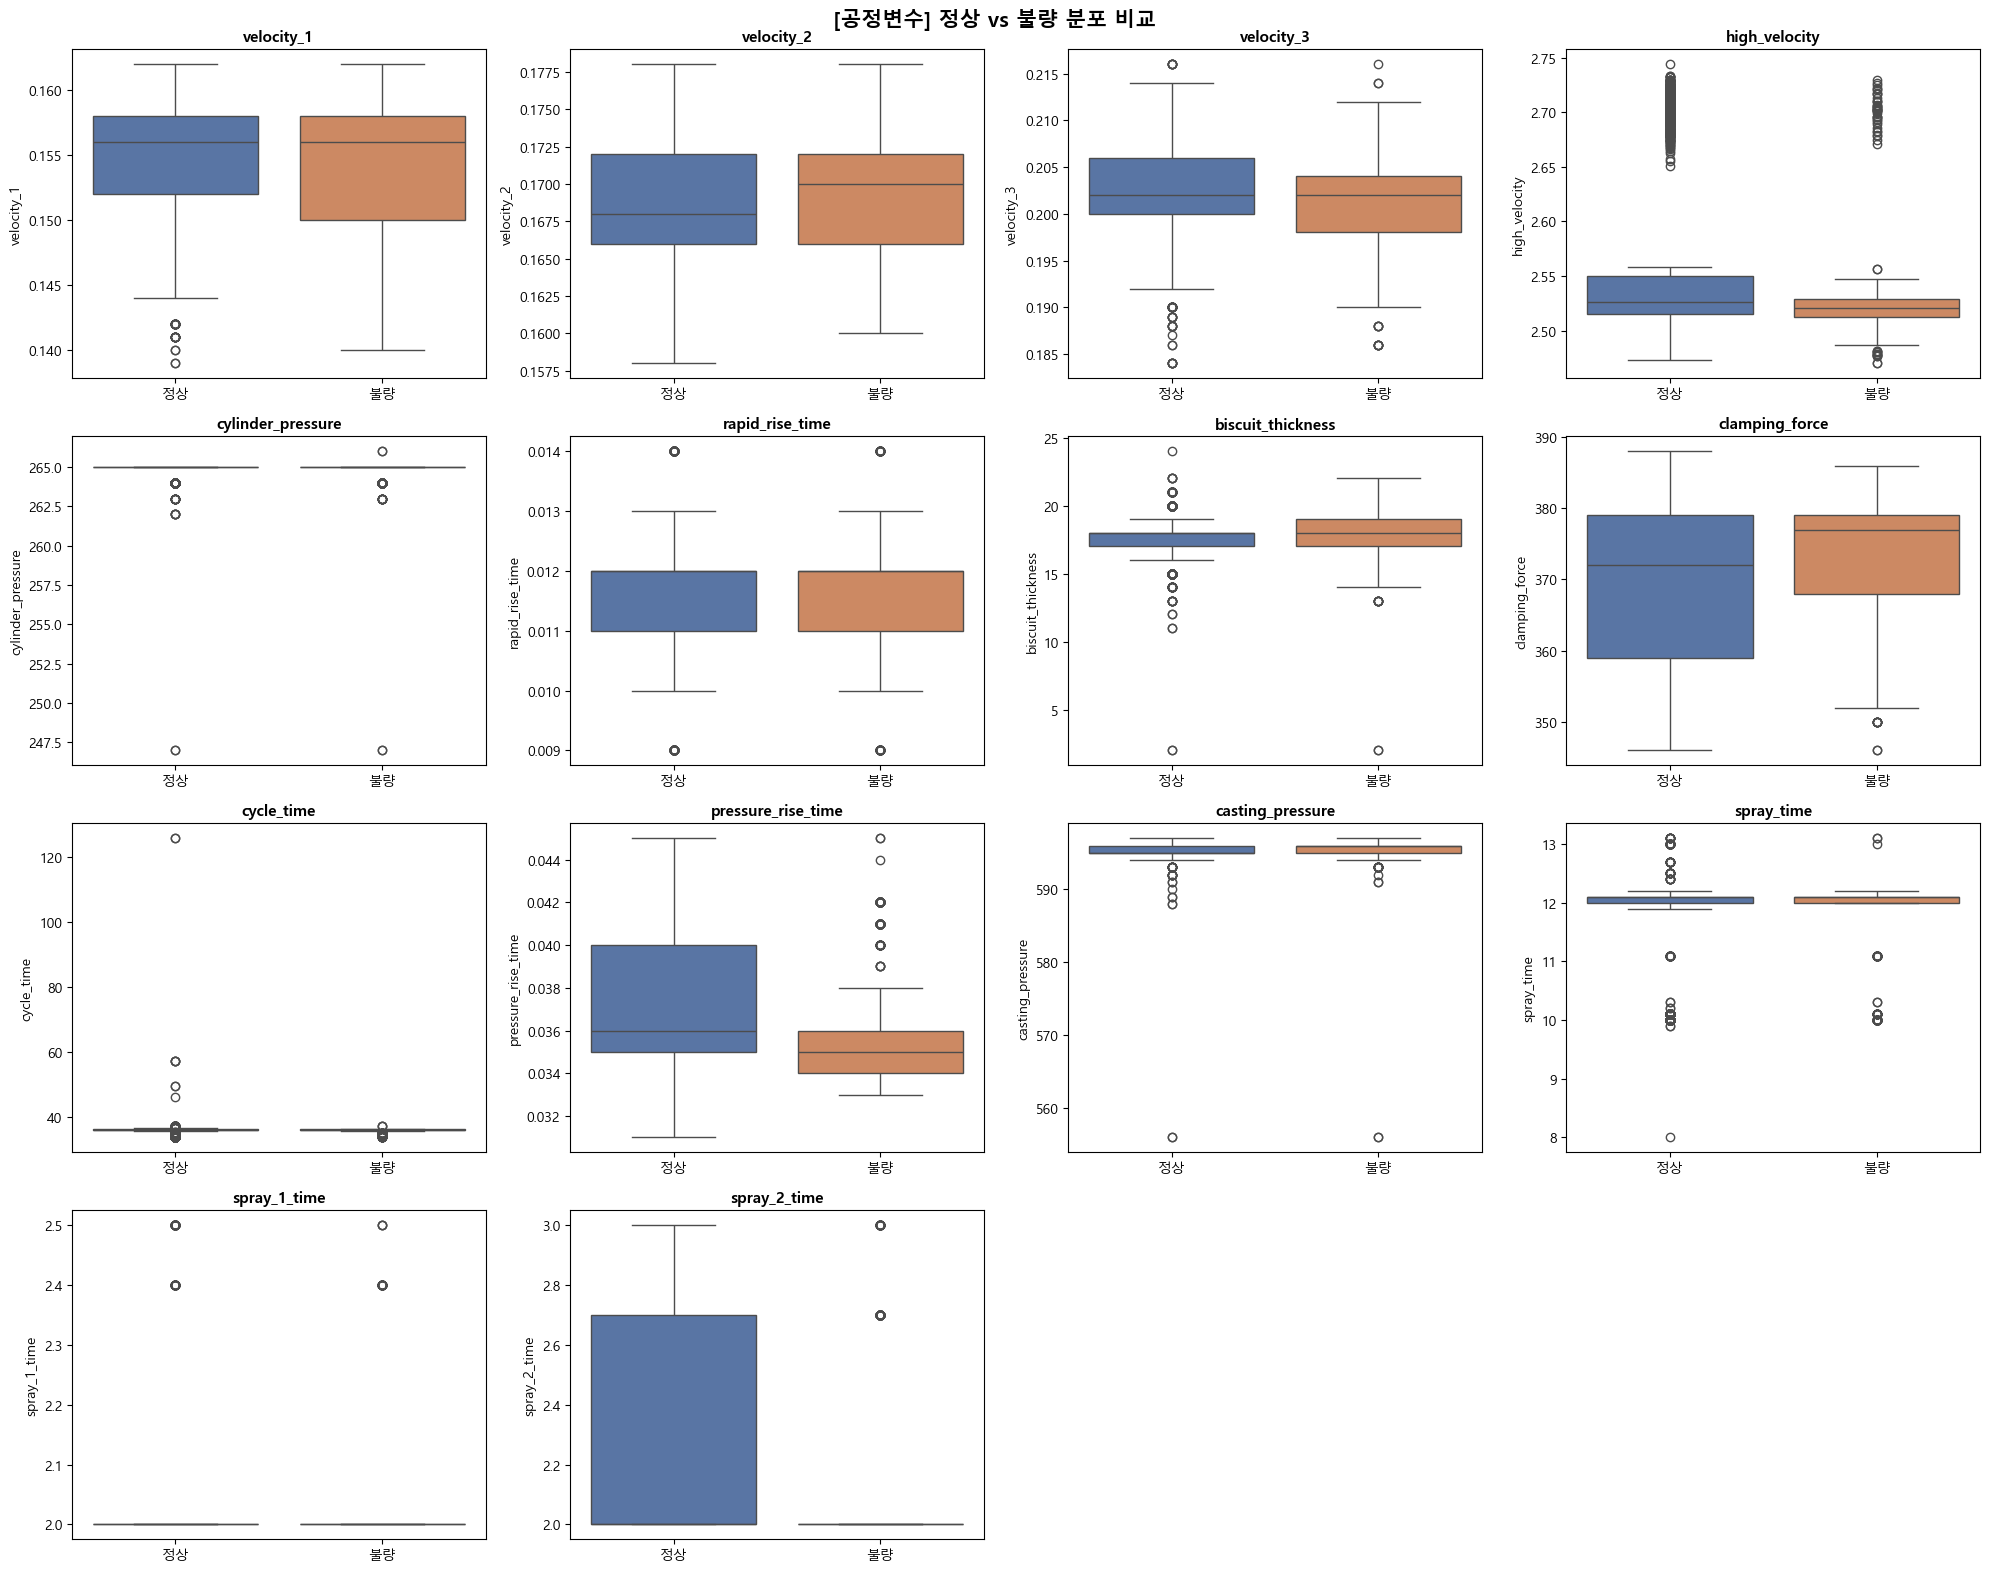

In [71]:
# process 관련 변수의 박스플롯
boxplot_of_process_2 = plot_boxplots(df_original_2_1, PROCESS_COLS, "공정변수")

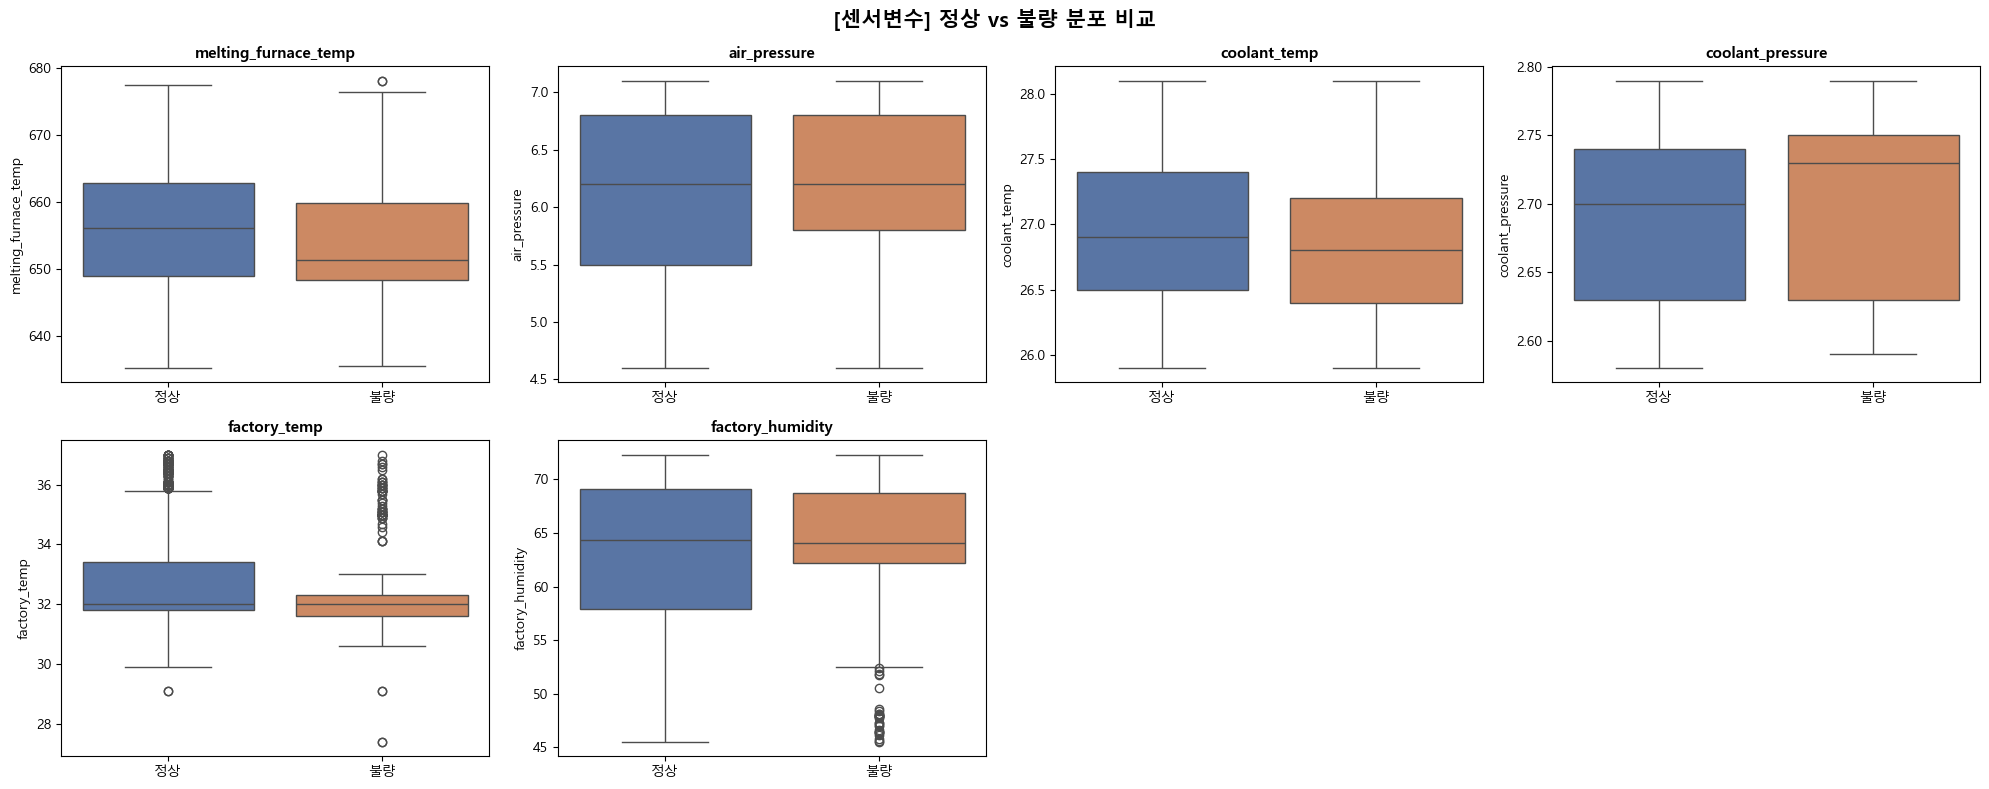

In [72]:
boxplot_of_sensor_2 = plot_boxplots(df_original_2_1, SENSOR_COLS, "센서변수")

In [73]:
print("정상 제품의 기술통계량")
df_original_2_1[df_original_2_1["is_defect"] == 0].describe().T

정상 제품의 기술통계량


,count,mean,std,min,25%,50%,75%,max
velocity_1,2382.0,0.154572,0.004797,0.139,0.152,0.156,0.15800,0.162
velocity_2,2382.0,0.168465,0.004005,0.158,0.166,0.168,0.17200,0.178
velocity_3,2382.0,0.202538,0.004979,0.184,0.200,0.202,0.20600,0.216
high_velocity,2382.0,2.563503,0.079042,2.473,2.515,2.526,2.54975,2.744
cylinder_pressure,2382.0,264.743493,0.685934,247.000,265.000,265.000,265.00000,265.000
rapid_rise_time,2382.0,0.011663,0.000869,0.009,0.011,0.012,0.01200,0.014
biscuit_thickness,2382.0,17.573468,1.462199,2.000,17.000,18.000,18.00000,24.000
clamping_force,2382.0,369.435348,10.532435,346.000,359.000,372.000,379.00000,388.000
cycle_time,2382.0,35.683963,2.938025,33.600,35.800,36.000,36.10000,125.900
pressure_rise_time,2382.0,0.036798,0.002940,0.031,0.035,0.036,0.04000,0.045


In [74]:
print("불량제품의 기술통계량")
df_original_2_1[df_original_2_1["is_defect"] == 1].describe().T

불량제품의 기술통계량


,count,mean,std,min,25%,50%,75%,max
velocity_1,946.0,0.154222,0.004933,0.140,0.150,0.156,0.158,0.162
velocity_2,946.0,0.169010,0.004042,0.160,0.166,0.170,0.172,0.178
velocity_3,946.0,0.201514,0.004811,0.186,0.198,0.202,0.204,0.216
high_velocity,946.0,2.527416,0.038946,2.470,2.512,2.521,2.529,2.730
cylinder_pressure,946.0,264.816068,0.907346,247.000,265.000,265.000,265.000,266.000
rapid_rise_time,946.0,0.011654,0.000931,0.009,0.011,0.012,0.012,0.014
biscuit_thickness,946.0,17.628964,1.565084,2.000,17.000,18.000,19.000,22.000
clamping_force,946.0,372.626850,8.756632,346.000,368.000,377.000,379.000,386.000
cycle_time,946.0,35.757400,0.648884,33.700,35.900,36.000,36.100,37.000
pressure_rise_time,946.0,0.036236,0.002925,0.033,0.034,0.035,0.036,0.045


In [75]:
def interpret_cohens_d(d):
    if d < 0.2:   
        return "작음"
    elif d < 0.5: 
        return "중간"
    else:         
        return "큼"

In [76]:
# Welch's t-test

ALL_COLS = PROCESS_COLS + SENSOR_COLS

result = []

alpha = 0.05

for col in ALL_COLS:
    g0 = df_original_2_1.loc[df_original_2_1["is_defect"] == 0, col]
    g1 = df_original_2_1.loc[df_original_2_1["is_defect"] == 1, col]
    
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
    
    # Cohen's d
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = (g1.mean() - g0.mean()) / pooled_std
    
    result.append({
        "요인":       col,
        "정상 제품의 평균": round(g0.mean(), 4),
        "불량 제품의 평균": round(g1.mean(), 4),
        "t-통계량": round(t_stat, 4),
        "Cohen's d": round(cohens_d, 4),
        "효과크기 해석": interpret_cohens_d(abs(cohens_d)),
        "p-value": float(f"{p_val:.4e}"),
    })

df_welchs = pd.DataFrame(result)

df_welchs['통계적 유의성 여부'] = df_welchs['p-value'] < alpha

display(df_welchs)

,요인,정상 제품의 평균,불량 제품의 평균,t-통계량,Cohen's d,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,0.1546,0.1542,1.8618,-0.0720,작음,6.280600e-02,False
1,velocity_2,0.1685,0.1690,-3.5163,0.1354,작음,4.489700e-04,True
2,velocity_3,0.2025,0.2015,5.4836,-0.2092,중간,4.760000e-08,True
3,high_velocity,2.5635,2.5274,17.5537,-0.5792,큼,6.444600e-66,True
4,cylinder_pressure,264.7435,264.8161,-2.2210,0.0902,작음,2.651400e-02,True
5,rapid_rise_time,0.0117,0.0117,0.2435,-0.0095,작음,8.076300e-01,False
6,biscuit_thickness,17.5735,17.6290,-0.9398,0.0366,작음,3.474500e-01,False
7,clamping_force,369.4353,372.6268,-8.9336,0.3295,중간,8.894600e-19,True
8,cycle_time,35.6840,35.7574,-1.1513,0.0345,작음,2.497200e-01,False
9,pressure_rise_time,0.0368,0.0362,4.9924,-0.1916,작음,6.559500e-07,True


In [77]:
def interpret_rbc(r):
    if r < 0.1:   
        return "작음"
    elif r < 0.3: 
        return "중간"
    else:         
        return "큼"

In [80]:
# Mann-Whitney U
result_mwu = []
for col in ALL_COLS:
    g0 = df_original_2_1.loc[df_original_2_1["is_defect"] == 0, col]
    g1 = df_original_2_1.loc[df_original_2_1["is_defect"] == 1, col]
    
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    
    # Rank-biserial correlation (효과 크기)
    r_rbc = 1 - (2 * u_stat) / (len(g0) * len(g1))
    
    result_mwu.append({
        "요인": col,
        "U-통계량":round(u_stat, 4),
        "rank-biserial r":round(r_rbc, 4),
        "효과크기 해석":interpret_rbc(abs(r_rbc)),
        "p-value":float(f"{p_val:.4e}"),
    })

df_mwu = pd.DataFrame(result_mwu)

df_mwu["통계적 유의성 여부"] = df_mwu["p-value"] < alpha

display(df_mwu)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,1170851.5,-0.0392,작음,7.495100e-02,False
1,velocity_2,1036119.5,0.0804,작음,2.636200e-04,True
2,velocity_3,1258631.0,-0.1171,중간,1.099600e-07,True
3,high_velocity,1370848.0,-0.2167,중간,1.543600e-22,True
4,cylinder_pressure,1021614.0,0.0933,작음,2.220200e-09,True
5,rapid_rise_time,1122143.5,0.0040,작음,8.314500e-01,False
6,biscuit_thickness,1078991.5,0.0423,작음,5.027400e-02,False
7,clamping_force,980118.5,0.1301,중간,4.069000e-09,True
8,cycle_time,1015785.5,0.0984,작음,6.478400e-06,True
9,pressure_rise_time,1263975.5,-0.1219,중간,2.404100e-08,True
